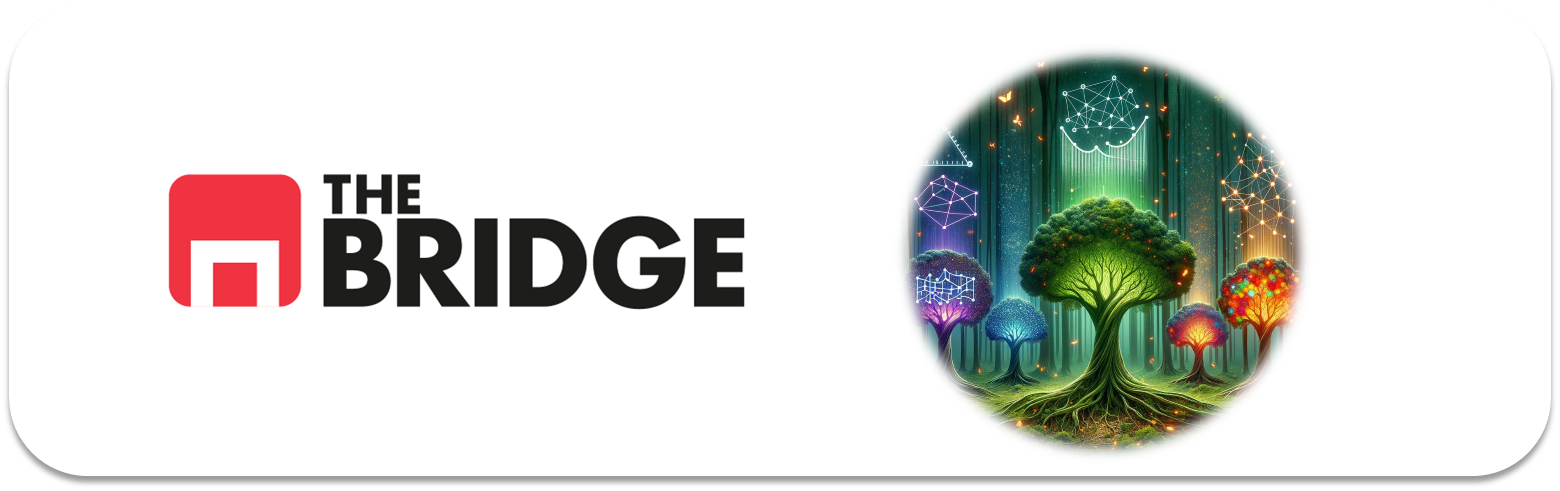

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from bootcampviztools import pinta_distribucion_categoricas

from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

#### Carga del dataset y primer vistazo:

In [123]:
df_bank = pd.read_csv("./data/bank-full.csv", sep=";")

In [124]:
df = df_bank.copy()

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [126]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [127]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#### Split de train y test:

In [128]:
train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 44)

#### Determinación de features categóricas y numércias:

In [129]:
features_cat = ["job", "marital", "education", "contact", "month", "default", "housing", "loan", "poutcome"]
features_num = [col for col in train_set.columns if col not in features_cat and col != "y"]
if "duration" in features_num:
    features_num.remove("duration")
target = "y"

#### Mini-EDA sobre train_set:

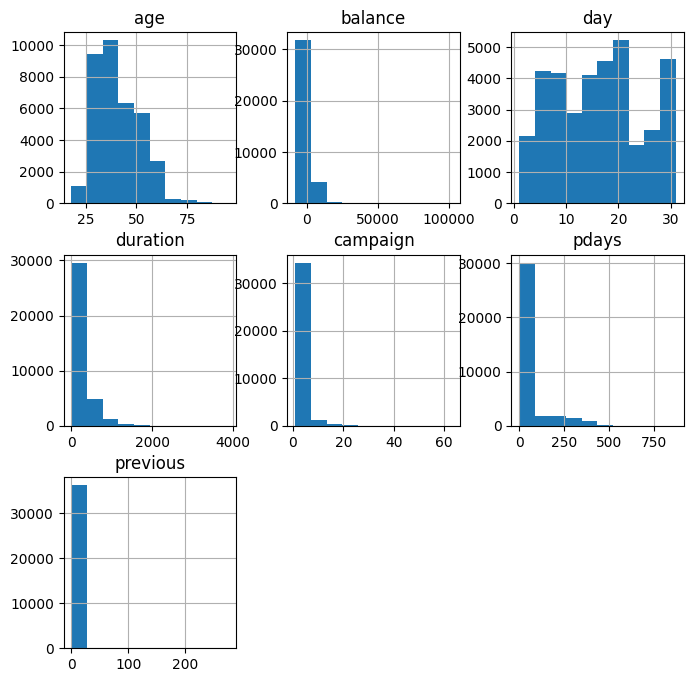

In [130]:
train_set.hist(figsize=(8,8));

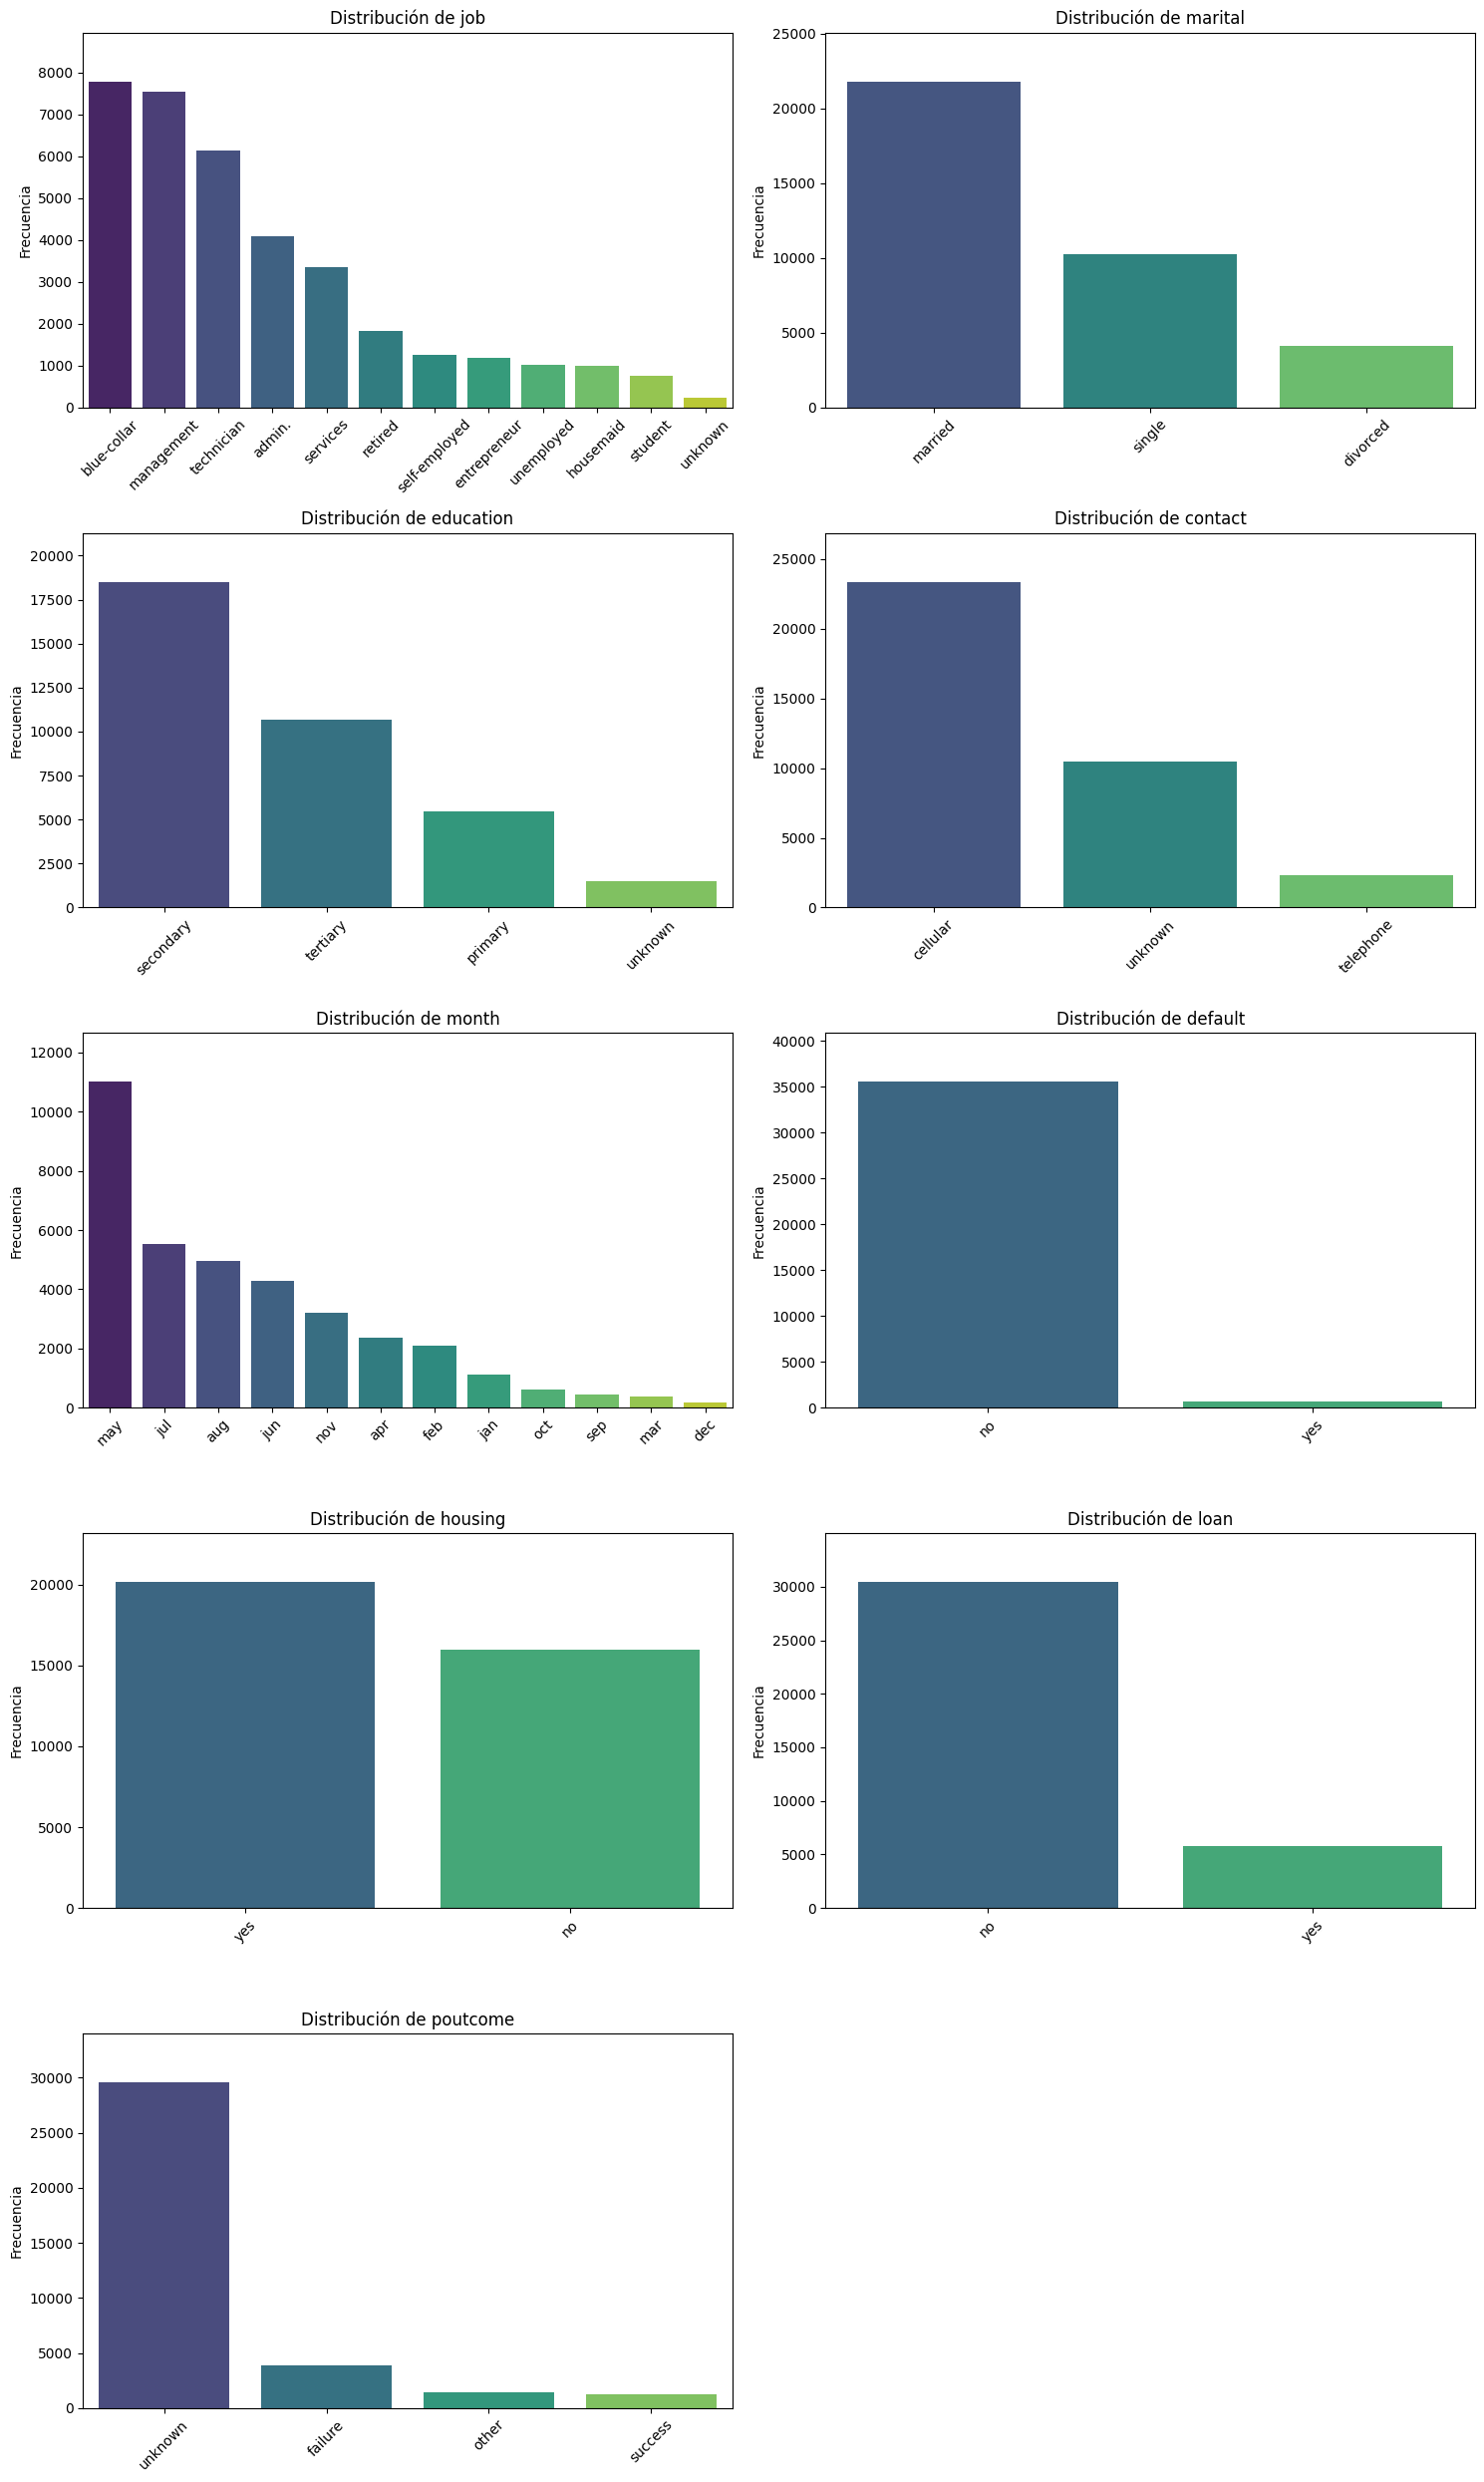

In [131]:
pinta_distribucion_categoricas(train_set, features_cat)

#### Preporcessing de train_set:

In [132]:
cols_to_encode = [
    col for col in features_cat
    if train_set[col].dtype != "int64" and train_set[col].dtype != "float64"
]

ord_encoder = OrdinalEncoder()

train_set[cols_to_encode] = ord_encoder.fit_transform(
    train_set[cols_to_encode]
)

target_encoder = OrdinalEncoder()

train_set[[target]] = target_encoder.fit_transform(
    train_set[[target]]
)

In [133]:
for feat_num in features_num:
    
    if feat_num != "day" and train_set[feat_num].min() > -1:
        
        train_set[feat_num] = np.log1p(train_set[feat_num])

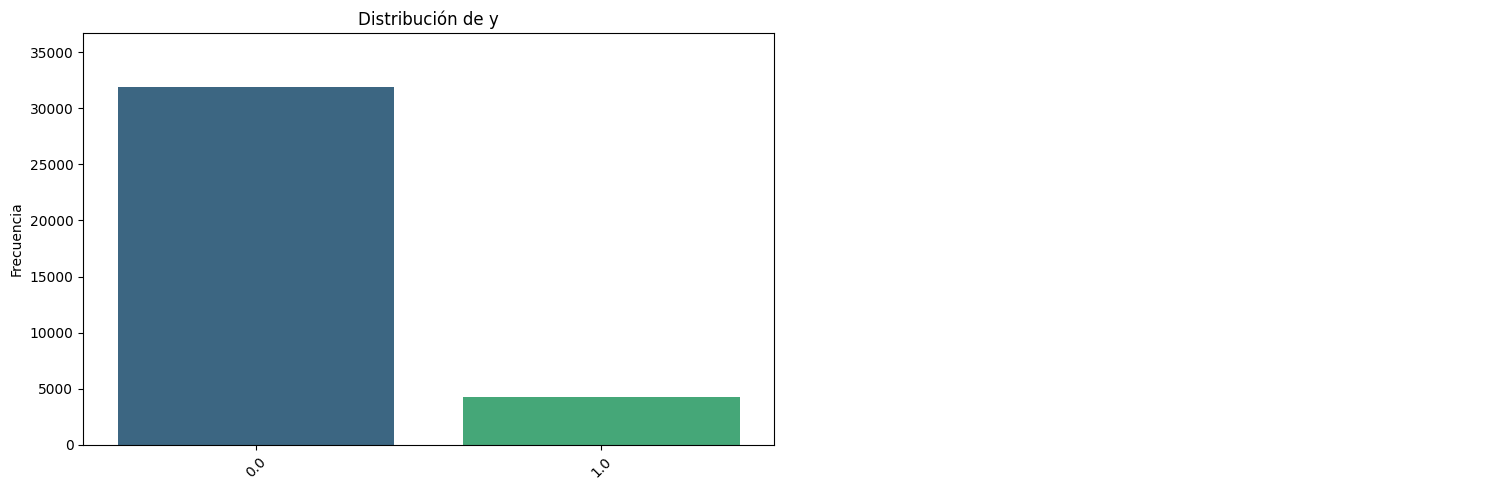

In [134]:
pinta_distribucion_categoricas(train_set, target)

#### Análisis de correlación entre features y target:

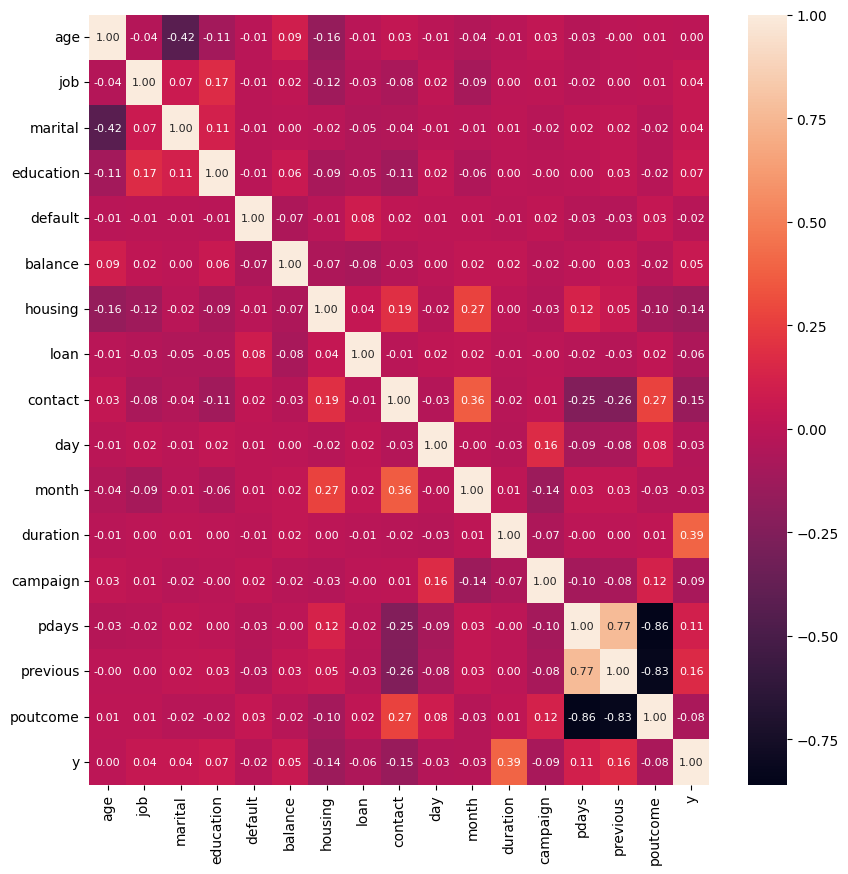

In [135]:
plt.figure(figsize=(10,10))

sns.heatmap(train_set.corr(numeric_only=True), annot=True, fmt = ".2f", annot_kws = {"size": 8})

plt.show()

Aunque algunas variables presentan baja correlación lineal con el target, se decide mantenerlas debido a que los modelos basados en árboles pueden capturar relaciones no lineales e interacciones entre variables.

In [136]:
features = features_cat + features_num

In [137]:
X_train = train_set[features]
y_train = train_set[target]

#### Aplicamos a test_set las transformaciones realizadas sobre train_set:

In [138]:
test_set[cols_to_encode] = ord_encoder.transform(test_set[cols_to_encode])
        
test_set[[target]] = target_encoder.transform(test_set[[target]])

for feat_num in features_num:
    
    if feat_num != "day" and test_set[feat_num].min() > -1:
        
        test_set[feat_num] = np.log1p(test_set[feat_num])

In [139]:
X_test = test_set[features]
y_test = test_set[target]

In [140]:
train_set.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
31162,4.007333,1.0,1.0,0.0,0.0,258,0.0,0.0,1.0,26,3.0,29,0.693147,-1,0.000000,3.0,0.0
19589,3.988984,1.0,1.0,0.0,0.0,787,1.0,1.0,0.0,7,1.0,119,1.098612,-1,0.000000,3.0,0.0
15232,4.007333,4.0,1.0,2.0,0.0,364,1.0,0.0,0.0,17,5.0,301,0.693147,-1,0.000000,3.0,0.0
25253,3.610918,9.0,2.0,0.0,0.0,2169,1.0,0.0,0.0,18,9.0,133,1.098612,110,1.386294,1.0,0.0
30318,3.583519,0.0,1.0,2.0,0.0,429,1.0,0.0,0.0,5,3.0,143,1.098612,-1,0.000000,3.0,0.0


#### Entrenamiento y evalación del modelo baseline (sin hiperparámetros):

In [141]:
tree = DecisionTreeClassifier(random_state=42,
                              class_weight="balanced")

tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [142]:
y_pred_tree = tree.predict(X_test)

              precision    recall  f1-score   support

         0.0       0.90      0.91      0.91      7985
         1.0       0.28      0.28      0.28      1058

    accuracy                           0.83      9043
   macro avg       0.59      0.59      0.59      9043
weighted avg       0.83      0.83      0.83      9043



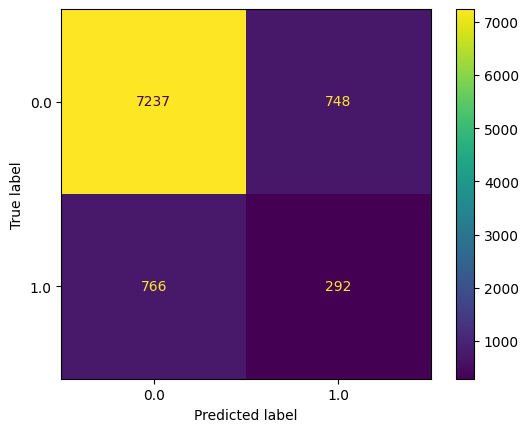

In [143]:
print(classification_report(y_test, y_pred_tree))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)

#### Optimización de hiperparámetros:

Utilización de RandomizedSearchCV para explorar rápidamente distintas combinaciones de hiperparámetros y posteriormente GridSearchCV para refinar la búsqueda alrededor de los mejores resultados encontrados:

Random Search:

In [144]:
param_grid = {
    "max_depth": [1,2,4,8,None],
    "min_samples_leaf": [1,10,20,40,80],
    "max_features": ["sqrt","log2", None],
    "class_weight": ["balanced", None]
}

tree_rand_search = RandomizedSearchCV(tree,
                               cv=3,
                               n_iter=20,
                               param_distributions=param_grid,
                               scoring="accuracy")

tree_rand_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [145]:
print(f"Best Score Random Search: {tree_rand_search.best_score_}")
print(f"Best Params Random Search: {tree_rand_search.best_params_}")

Best Score Random Search: 0.8910639239106392
Best Params Random Search: {'min_samples_leaf': 80, 'max_features': None, 'max_depth': None, 'class_weight': None}


Grid Search:

In [154]:
param_grid_2 = {
    "max_depth": [3,4,5],
    "min_samples_leaf": [30,40,50,60],
    "max_features": ["sqrt","log2", None],
    "class_weight": ["balanced", None]
}

tree_grid_search = GridSearchCV(tree,
                                cv=3,
                                param_grid=param_grid_2,
                                scoring="accuracy")

tree_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [3, 4, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [30, 40, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [155]:
print(f"Best Score Grid Search: {tree_grid_search.best_score_}")
print(f"Best Params Grid Search: {tree_grid_search.best_params_}")

Best Score Grid Search: 0.8925569564255694
Best Params Grid Search: {'class_weight': None, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 40}


              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94      7985
         1.0       0.65      0.20      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



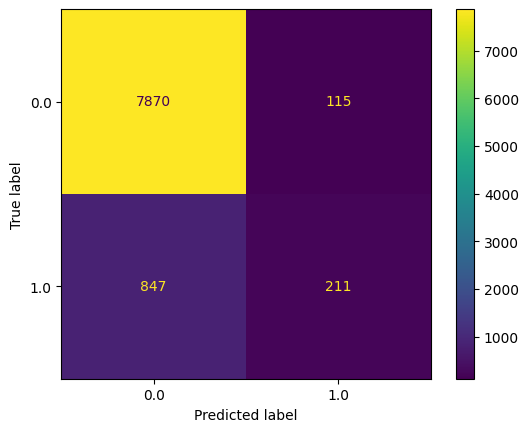

In [156]:
y_pred_grid_search = tree_grid_search.predict(X_test)

print(classification_report(y_test, y_pred_grid_search))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_grid_search)


#### Comparación con el modelo baseline y conclusiones:

In [157]:
report_base = classification_report(
    y_test,
    y_pred_tree,
    output_dict=True
)

report_opt = classification_report(
    y_test,
    y_pred_grid_search,
    output_dict=True
)

comparacion = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision Clase 1",
        "Recall Clase 1",
        "F1 Clase 1"
    ],
    
    "Baseline": [
        report_base["accuracy"],
        report_base["1.0"]["precision"],
        report_base["1.0"]["recall"],
        report_base["1.0"]["f1-score"]
    ],
    
    "Optimizado": [
        report_opt["accuracy"],
        report_opt["1.0"]["precision"],
        report_opt["1.0"]["recall"],
        report_opt["1.0"]["f1-score"]
    ]
})

comparacion = comparacion.round(3)

comparacion

,Métrica,Baseline,Optimizado
0,Accuracy,0.833,0.894
1,Precision Clase 1,0.281,0.647
2,Recall Clase 1,0.276,0.199
3,F1 Clase 1,0.278,0.305


El modelo optimizado mejora el accuracy general y la precisión de la clase minoritaria. Sin embargo, reduce el recall, siendo un modelo más conservador en la detección de positivos. El F1-score mejora, por lo que la optimización de hiperparámetros parece haber tenido un efecto positivo global.

En este problema puede ser preferible priorizar el recall de la clase positiva frente a la precision, ya que los falsos negativos implican perder potenciales clientes interesados en el depósito, mientras que los falsos positivos únicamente suponen contactar clientes que finalmente no contratarán el producto.

#### Feature Importance:

In [158]:
pd.Series(
    tree_grid_search.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

poutcome     0.374346
month        0.214780
pdays        0.171038
age          0.105233
housing      0.056226
contact      0.056202
balance      0.011949
day          0.008023
job          0.002203
marital      0.000000
education    0.000000
default      0.000000
loan         0.000000
campaign     0.000000
previous     0.000000
dtype: float64

In [159]:
print(tree_grid_search.score(X_train, y_train))
print(tree_grid_search.score(X_test, y_test))

0.8942711789427118
0.8936193741015149


Las métricas obtenidas en train y test son similares, lo que sugiere que el modelo generaliza correctamente y no presenta un overfiting significativo.